## Multifísica

Los problemas Tradicionales de las ciencias e ingenierias involucran la interaccion de multiples campos físicos como los pueden ser la interaccion en la estructura de los fluidos, las ecuaciones que gorbiernan estos problemas son normalmente un conjunto de PDE no lineales, haciendo asi sus soluciones bastante complicadas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| dispositivo:', device)

PyTorch 2.11.0+cpu | dispositivo: cpu


## 1. Arquitectura multifísica

Se introducen las variables de espacio y tiempo para computar las salidas de los valores de velocidad, presion y desplazamiento del solido en el espacio.

In [2]:
# Red Multi-Cabeza con Backbone Compartido
# Entradas: (x, y, t)
# Salidas : u, v (velocidad fluido), p (presion), dx, dy (desplazamiento solido)
class FSINet(nn.Module):
    def __init__(self, layers=[3, 64, 64, 64]):
        super(FSINet, self).__init__()
        backbone = []
        for i in range(len(layers) - 1):
            backbone += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        self.backbone = nn.Sequential(*backbone)
        h = layers[-1]
        self.head_u  = nn.Linear(h, 1)
        self.head_v  = nn.Linear(h, 1)
        self.head_p  = nn.Linear(h, 1)
        self.head_dx = nn.Linear(h, 1)
        self.head_dy = nn.Linear(h, 1)

    def forward(self, x, y, t):
        feat = self.backbone(torch.cat([x, y, t], dim=1))
        return (self.head_u(feat), self.head_v(feat), self.head_p(feat),
                self.head_dx(feat), self.head_dy(feat))

## 2. Definición del PINN con acoplamiento de PDEs y correcion de pesos.

Fluido:

$\Omega _f: \frac{\partial u}{\partial t} + (u.\nabla)u=-\nabla_ p+v\nabla^2u$, $\nabla . u=0$ 

Solido:

$\Omega _s: \rho _s \frac{\partial^2d}{\partial t^2}=\nabla \sigma(d) + f_s$

Cinematica:

$u=\frac{\partial u}{\partial t}$

Dinámica:

$\sigma _f n=\sigma _s n$

y donde su función de perdida esta dada por:

$\mathcal{l} = \lambda _f\mathcal{l}_{NS} + \lambda _s\mathcal{l}_{Elastic}+\lambda_{b,f}\mathcal{l}_{b,f} + \lambda _{b,s} \mathcal{l}_{b,s} + \lambda _\Gamma\mathcal{l}_\Gamma$

donde la pérdida de la condición de acoplamiento es:

$\mathcal{l}_\Gamma= \lambda _{kin}||u-\frac{\partial\hat d}{\partial t}||_\Gamma ^2 + \lambda _{dyn}||\hat\sigma _f n-\hat\sigma _s n||_\Gamma ^2$

In [ ]:
class FSIPINN:
    def __init__(self, Xf, Xs, Xbc_f, Ubc, Xbc_s, Dbc, Xint,
                 nu=0.01, rho_s=1.0, lam=1.0, mu=0.5,
                 lam_f=1.0, lam_s=1.0, lam_bf=1.0, lam_bs=1.0, lam_G=2.0):
        def T(a, g=False):
            return torch.tensor(a, dtype=torch.float32, requires_grad=g)
        # Puntos de colocacion
        self.xf, self.yf, self.tf = T(Xf[:,0:1],True), T(Xf[:,1:2],True), T(Xf[:,2:3],True)
        self.xs, self.ys, self.ts = T(Xs[:,0:1],True), T(Xs[:,1:2],True), T(Xs[:,2:3],True)
        # Condiciones de frontera fluido
        self.xbf=T(Xbc_f[:,0:1]); self.ybf=T(Xbc_f[:,1:2]); self.tbf=T(Xbc_f[:,2:3])
        self.ubc=T(Ubc[:,0:1]);   self.vbc=T(Ubc[:,1:2])
        # Condiciones de frontera solido
        self.xbs=T(Xbc_s[:,0:1]); self.ybs=T(Xbc_s[:,1:2]); self.tbs=T(Xbc_s[:,2:3])
        self.dbc=T(Dbc[:,0:1])
        # Puntos de interfaz
        self.xi=T(Xint[:,0:1],True); self.yi=T(Xint[:,1:2],True); self.ti=T(Xint[:,2:3],True)
        # Parametros fisicos
        self.nu=nu; self.rho_s=rho_s; self.lam=lam; self.mu_e=mu
        # Pesos de la funcion de perdida
        self.lam_f=lam_f; self.lam_s=lam_s; self.lam_bf=lam_bf
        self.lam_bs=lam_bs; self.lam_G=lam_G
        # Red y optimizador
        self.net = FSINet([3,64,64,64])
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr=1e-3)
        self.losses = []

    def _d(self, f, v):
        return torch.autograd.grad(f, v, grad_outputs=torch.ones_like(f), create_graph=True)[0]

    def ns_residuals(self, x, y, t):
        u, v, p, _, _ = self.net(x, y, t)
        u_t=self._d(u,t); u_x=self._d(u,x); u_y=self._d(u,y)
        v_t=self._d(v,t); v_x=self._d(v,x); v_y=self._d(v,y)
        p_x=self._d(p,x); p_y=self._d(p,y)
        u_xx=self._d(u_x,x); u_yy=self._d(u_y,y)
        v_xx=self._d(v_x,x); v_yy=self._d(v_y,y)
        res_u = u_t + u*u_x + v*u_y + p_x - self.nu*(u_xx+u_yy)
        res_v = v_t + u*v_x + v*v_y + p_y - self.nu*(v_xx+v_yy)
        res_c = u_x + v_y
        return res_u, res_v, res_c

    def elastic_residuals(self, x, y, t):
        _, _, _, dx, dy = self.net(x, y, t)
        lam=self.lam; mu=self.mu_e
        dx_t=self._d(dx,t); dy_t=self._d(dy,t)
        dx_tt=self._d(dx_t,t); dy_tt=self._d(dy_t,t)
        dx_x=self._d(dx,x); dx_y=self._d(dx,y)
        dy_x=self._d(dy,x); dy_y=self._d(dy,y)
        eps_xx=dx_x; eps_yy=dy_y; eps_xy=0.5*(dx_y+dy_x)
        tr=eps_xx+eps_yy
        s_xx=lam*tr+2*mu*eps_xx; s_yy=lam*tr+2*mu*eps_yy; s_xy=2*mu*eps_xy
        div_sx=self._d(s_xx,x)+self._d(s_xy,y)
        div_sy=self._d(s_xy,x)+self._d(s_yy,y)
        return self.rho_s*dx_tt-div_sx, self.rho_s*dy_tt-div_sy

    def interface_loss(self, x, y, t):
        u_i,v_i,p_i,dx_i,dy_i = self.net(x,y,t)
        # Cinematica: u = dd/dt
        dx_t=self._d(dx_i,t); dy_t=self._d(dy_i,t)
        L_kin = torch.mean((u_i-dx_t)**2 + (v_i-dy_t)**2)
        # Dinamica: sigma_f.n = sigma_s.n (aprox. n=(0,1))
        L_dyn = torch.mean((p_i - self.lam*dy_i)**2)
        return L_kin + L_dyn

    def train(self, epochs=3000):
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            ru,rv,rc = self.ns_residuals(self.xf,self.yf,self.tf)
            L_NS = torch.mean(ru**2+rv**2+rc**2)
            rex,rey = self.elastic_residuals(self.xs,self.ys,self.ts)
            L_El = torch.mean(rex**2+rey**2)
            u_p,v_p,_,_,_ = self.net(self.xbf,self.ybf,self.tbf)
            L_bf = torch.mean((u_p-self.ubc)**2+(v_p-self.vbc)**2)
            _,_,_,dx_p,_ = self.net(self.xbs,self.ybs,self.tbs)
            L_bs = torch.mean((dx_p-self.dbc)**2)
            L_G  = self.interface_loss(self.xi,self.yi,self.ti)
            loss = (self.lam_f*L_NS + self.lam_s*L_El +
                    self.lam_bf*L_bf + self.lam_bs*L_bs + self.lam_G*L_G)
            loss.backward()
            self.optimizer.step()
            self.losses.append(loss.item())
            if epoch % 500 == 0:
                msg = ('Epoch %5d | NS: %.3e  Elastic: %.3e  BC_f: %.3e  BC_s: %.3e  Interfaz: %.3e'
                       % (epoch, L_NS.item(), L_El.item(), L_bf.item(), L_bs.item(), L_G.item()))
                print(msg)

## 3. Configuración del entorno de simulación y datos para el problema FSI

 Dominio: $x \in [0,1]$, $y \in [0,1]$, $t \in [0,1]$

 Fluido : $\Omega _f \rightarrow y \in [0.5, 1.0]$

 Solido : $\Omega _s \rightarrow y \in [0.0, 0.5]$

 Interfaz Gamma: $y = 0.5$

### Solucion analitica de referencia:
   $u  =  \sin(\pi x) \cos(\pi y) e^{-t}    $ (vel. x, div=0)

   $v  = -\cos(\pi x) \sin(\pi y) e^{-t}    $ (vel. y)

   $p  =  0.5 \cos(\pi x) \cos(\pi y) e^{-t}$ (presion)
   
   $dx =  0.01 \sin(\pi x) \sin(2 \pi t)     $ (desplaz. x solido)

   $dy =  0.01 \cos(\pi x) \sin(2 \pi t)     $ (desplaz. y solido)



In [ ]:

np.random.seed(42)
Nf=2000; Ns=1500; Nbc=200; Ni=300

# Dominio fluido
xf_=np.random.rand(Nf,1); yf_=np.random.rand(Nf,1)*0.5+0.5; tf_=np.random.rand(Nf,1)
Xf=np.hstack([xf_,yf_,tf_])

# Dominio solido
xs_=np.random.rand(Ns,1); ys_=np.random.rand(Ns,1)*0.5; ts_=np.random.rand(Ns,1)
Xs=np.hstack([xs_,ys_,ts_])

# BC fluido: pared y=1 y condicion inicial t=0 en interfaz
half=Nbc//2
xbf1=np.random.rand(half,1); ybf1=np.ones((half,1));     tbf1=np.random.rand(half,1)
xbf2=np.random.rand(half,1); ybf2=np.ones((half,1))*0.5; tbf2=np.zeros((half,1))
Xbc_f=np.vstack([np.hstack([xbf1,ybf1,tbf1]),np.hstack([xbf2,ybf2,tbf2])])
U_bc= np.sin(np.pi*Xbc_f[:,0:1])*np.cos(np.pi*Xbc_f[:,1:2])*np.exp(-Xbc_f[:,2:3])
V_bc=-np.cos(np.pi*Xbc_f[:,0:1])*np.sin(np.pi*Xbc_f[:,1:2])*np.exp(-Xbc_f[:,2:3])
Ubc=np.hstack([U_bc,V_bc])

# BC solido: base fija y=0
xbs_=np.random.rand(Nbc,1); ybs_=np.zeros((Nbc,1)); tbs_=np.random.rand(Nbc,1)
Xbc_s=np.hstack([xbs_,ybs_,tbs_])
Dbc=np.zeros((Nbc,1))

# Interfaz Gamma: y=0.5
xi_=np.random.rand(Ni,1); yi_=np.ones((Ni,1))*0.5; ti_=np.random.rand(Ni,1)
Xint=np.hstack([xi_,yi_,ti_])

# Instanciar y entrenar
fsi_pinn = FSIPINN(
    Xf=Xf, Xs=Xs, Xbc_f=Xbc_f, Ubc=Ubc, Xbc_s=Xbc_s, Dbc=Dbc, Xint=Xint,
    nu=0.01, rho_s=1.0, lam=1.0, mu=0.5,
    lam_f=1.0, lam_s=1.0, lam_bf=1.0, lam_bs=1.0, lam_G=2.0
)
fsi_pinn.train(epochs=3000)

Epoch     0 | NS: 1.111e-01  Elastic: 3.163e-03  BC_f: 3.517e-01  BC_s: 4.027e-02  Interfaz: 5.953e-02
Epoch   500 | NS: 1.234e-02  Elastic: 1.425e-03  BC_f: 2.828e-02  BC_s: 4.583e-04  Interfaz: 2.738e-03
Epoch  1000 | NS: 4.986e-03  Elastic: 2.459e-03  BC_f: 1.076e-02  BC_s: 1.642e-04  Interfaz: 1.337e-03
Epoch  1500 | NS: 3.445e-03  Elastic: 1.008e-03  BC_f: 4.515e-03  BC_s: 8.628e-05  Interfaz: 7.595e-04
Epoch  2000 | NS: 2.767e-03  Elastic: 5.972e-04  BC_f: 2.897e-03  BC_s: 6.295e-05  Interfaz: 5.346e-04
Epoch  2500 | NS: 2.221e-03  Elastic: 4.560e-04  BC_f: 2.108e-03  BC_s: 4.809e-05  Interfaz: 4.333e-04


## 4. Post-procesamiento: Visualizacion de campos predichos vs solución de referencia

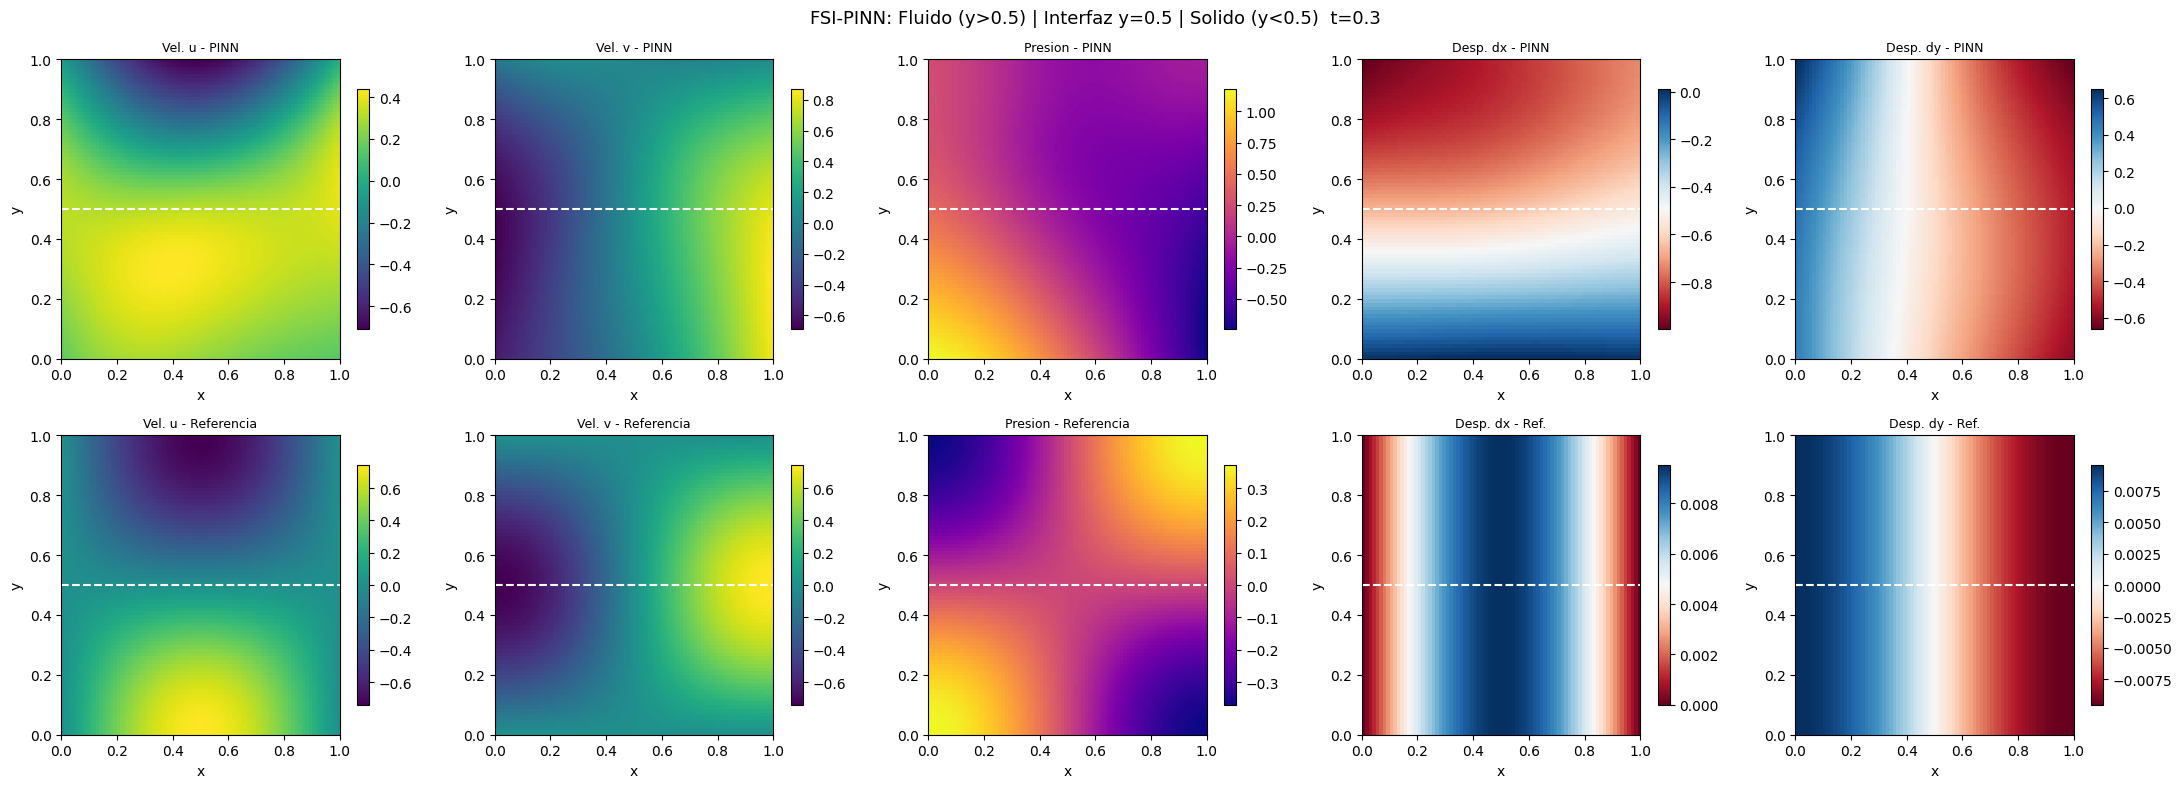

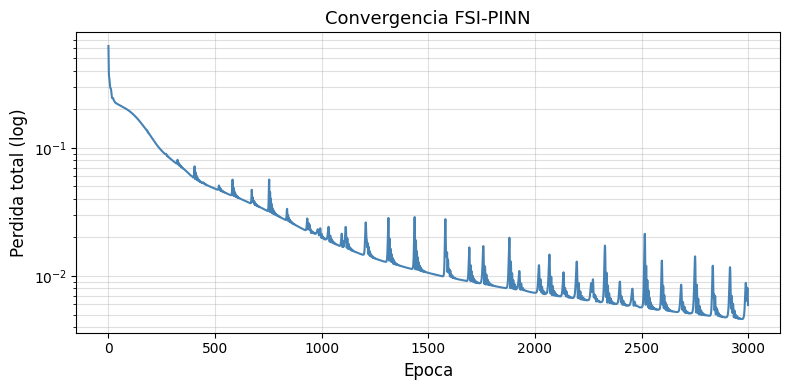

In [ ]:
t_fixed=0.3; Ng=80
x_lin=np.linspace(0,1,Ng); y_lin=np.linspace(0,1,Ng)
X_g,Y_g=np.meshgrid(x_lin,y_lin)
T_g=np.full_like(X_g,t_fixed)
Xtest=np.stack([X_g.ravel(),Y_g.ravel(),T_g.ravel()],axis=1)
xt=torch.tensor(Xtest[:,0:1],dtype=torch.float32)
yt=torch.tensor(Xtest[:,1:2],dtype=torch.float32)
tt=torch.tensor(Xtest[:,2:3],dtype=torch.float32)

with torch.no_grad():
    u_p,v_p,p_p,dx_p,dy_p = fsi_pinn.net(xt,yt,tt)

U_pred =u_p.numpy().reshape(Ng,Ng)
V_pred =v_p.numpy().reshape(Ng,Ng)
P_pred =p_p.numpy().reshape(Ng,Ng)
DX_pred=dx_p.numpy().reshape(Ng,Ng)
DY_pred=dy_p.numpy().reshape(Ng,Ng)

# Referencia analitica
U_ref = np.sin(np.pi*X_g)*np.cos(np.pi*Y_g)*np.exp(-t_fixed)
V_ref =-np.cos(np.pi*X_g)*np.sin(np.pi*Y_g)*np.exp(-t_fixed)
P_ref = 0.5*np.cos(np.pi*X_g)*np.cos(np.pi*Y_g)*np.exp(-t_fixed)
DX_ref= 0.01*np.sin(np.pi*X_g)*np.sin(2*np.pi*t_fixed)
DY_ref= 0.01*np.cos(np.pi*X_g)*np.sin(2*np.pi*t_fixed)

fig,axes=plt.subplots(2,5,figsize=(22,8))
campos=[
    (U_pred, 'Vel. u - PINN',       'viridis'),
    (V_pred, 'Vel. v - PINN',       'viridis'),
    (P_pred, 'Presion - PINN',      'plasma'),
    (DX_pred,'Desp. dx - PINN',     'RdBu'),
    (DY_pred,'Desp. dy - PINN',     'RdBu'),
    (U_ref,  'Vel. u - Referencia', 'viridis'),
    (V_ref,  'Vel. v - Referencia', 'viridis'),
    (P_ref,  'Presion - Referencia','plasma'),
    (DX_ref, 'Desp. dx - Ref.',     'RdBu'),
    (DY_ref, 'Desp. dy - Ref.',     'RdBu'),
]
for ax,(data,title,cmap) in zip(axes.ravel(),campos):
    im=ax.imshow(data,extent=[0,1,0,1],origin='lower',aspect='auto',cmap=cmap)
    ax.set_title(title,fontsize=9); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.axhline(0.5,color='white',lw=1.5,linestyle='--')
    plt.colorbar(im,ax=ax,shrink=0.8)

fig.suptitle('FSI-PINN: Fluido (y>0.5) | Interfaz y=0.5 | Solido (y<0.5)  t=%.1f' % t_fixed, fontsize=13)
plt.tight_layout(); plt.show()

# Curva de convergencia
fig2,ax2=plt.subplots(figsize=(8,4))
ax2.semilogy(fsi_pinn.losses,color='steelblue',lw=1.5)
ax2.set_xlabel('Epoca',fontsize=12)
ax2.set_ylabel('Perdida total (log)',fontsize=12)
ax2.set_title('Convergencia FSI-PINN',fontsize=13)
ax2.grid(True,which='both',alpha=0.4)
plt.tight_layout(); plt.show()